In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 

In [13]:
data = pd.read_csv("student_depression_dataset.csv")

print(data.head())

   id  Gender   Age           City Profession  Academic Pressure  \
0   2    Male  33.0  Visakhapatnam    Student                5.0   
1   8  Female  24.0      Bangalore    Student                2.0   
2  26    Male  31.0       Srinagar    Student                3.0   
3  30  Female  28.0       Varanasi    Student                3.0   
4  32  Female  25.0         Jaipur    Student                4.0   

   Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
0            0.0  8.97                 2.0               0.0   
1            0.0  5.90                 5.0               0.0   
2            0.0  7.03                 5.0               0.0   
3            0.0  5.59                 2.0               0.0   
4            0.0  8.13                 3.0               0.0   

        Sleep Duration Dietary Habits   Degree  \
0          '5-6 hours'        Healthy  B.Pharm   
1          '5-6 hours'       Moderate      BSc   
2  'Less than 5 hours'        Healthy       BA   
3     

In [14]:
data.isnull().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [16]:
data.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


In [17]:
# Strip stray quote characters that leaked into several string columns
str_cols = data.select_dtypes(include="object").columns.tolist() + \
           [c for c in data.columns if data[c].dtype.name == "str"]
for c in set(str_cols):
    data[c] = data[c].astype(str).str.strip().str.strip("'")


# Restrict to students (31 rows are working professionals with no academic-pressure signal)
data = data[data["Profession"] == "Student"].copy()


# Work Pressure / Job Satisfaction are >99.9% zero once restricted to students -> drop
data = data.drop(columns=["Work Pressure", "Job Satisfaction", "Profession"])  


# Drop rows with garbage City values (data-entry errors)
invalid_cities = ["Less Delhi", "Less than 5 Kalyan", "3.0", "Bhavna", "City", "Gaurav",
                   "Harsh", "Harsha", "Kibara", "M.Com", "M.Tech", "ME", "Mihir", "Nalini",
                   "Nalyan", "Nandini", "Rashi", "Reyansh", "Saanvi", "Vaanya"]
data = data[~data["City"].isin(invalid_cities)].copy()


# Drop rows with '?' Financial Stress, then cast to numeric
data = data[data["Financial Stress"] != "?"].copy()
data["Financial Stress"] = data["Financial Stress"].astype(float)


# Rename + encode binary columns
data = data.rename(columns={"Have you ever had suicidal thoughts ?": "Suicidal Thoughts History"})
data["Suicidal Thoughts History"] = data["Suicidal Thoughts History"].map({"Yes": 1, "No": 0})
data["Family History of Mental Illness"] = data["Family History of Mental Illness"].map({"Yes": 1, "No": 0})
data["Gender"] = data["Gender"].map({"Male": 1, "Female": 0})


data = data.drop(columns=["id"])


assert data.isna().sum().sum() == 0
print(f"Cleaned shape: {data.shape}")
data.head()

Cleaned shape: (27843, 14)


,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Suicidal Thoughts History,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,Visakhapatnam,5.0,8.97,2.0,5-6 hours,Healthy,B.Pharm,1,3.0,1.0,0,1
1,0,24.0,Bangalore,2.0,5.90,5.0,5-6 hours,Moderate,BSc,0,3.0,2.0,1,0
2,1,31.0,Srinagar,3.0,7.03,5.0,Less than 5 hours,Healthy,BA,0,9.0,1.0,1,0
3,0,28.0,Varanasi,3.0,5.59,2.0,7-8 hours,Moderate,BCA,1,4.0,5.0,1,1
4,0,25.0,Jaipur,4.0,8.13,3.0,5-6 hours,Moderate,M.Tech,1,1.0,1.0,0,0


### Exploratory Data Analysis


Depression
1    58.520993
0    41.479007
Name: proportion, dtype: float64


(0.0, 100.0)

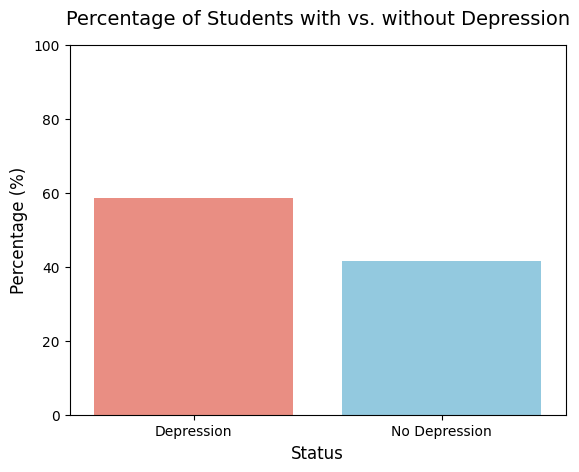

In [22]:
# 1. Calculate the percentage distribution of the target variable
depression_pct = data["Depression"].value_counts(normalize=True) * 100
print(depression_pct)

# Map the binary keys (1 and 0) to professional, readable string labels
labels = ['Depression' if index == 1 else 'No Depression' for index in depression_pct.index]

# 2. Create a bar plot for the percentage distribution of the target variable
ax = sns.barplot(
    x=labels, 
    y=depression_pct.values, 
    palette=["salmon", "skyblue"],
    hue=labels,
    legend=False
)

plt.title('Percentage of Students with vs. without Depression', fontsize=14, pad=15)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Status', fontsize=12)
plt.ylim(0, 100)

##### Academeic pressure is strongly associated with depression.

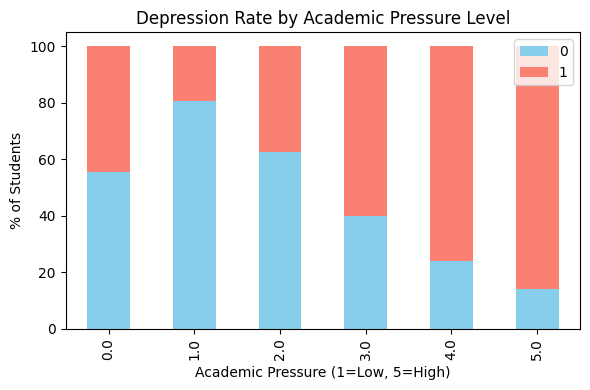

In [ ]:
ct = pd.crosstab(data["Academic Pressure"], data["Depression"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(6, 4))
ct.plot(kind="bar", stacked=True, ax=ax, color=['skyblue', 'salmon'])
ax.set_title("Depression Rate by Academic Pressure Level")
ax.set_xlabel("Academic Pressure (1=Low, 5=High)")
ax.set_ylabel("% of Students")
ax.legend(title="")
plt.tight_layout()
plt.show()


##### Suprisingly, CGPA does not show any relationship with depression.

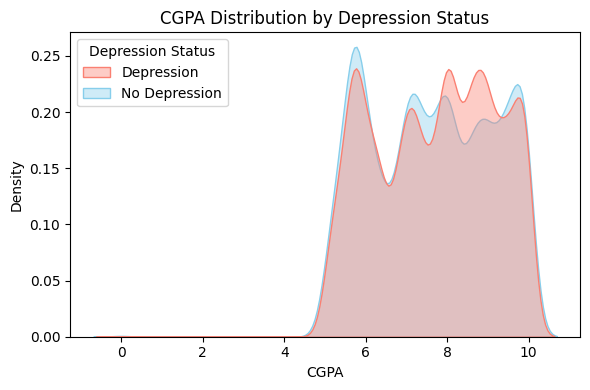

In [26]:
data['Depression Status'] = data['Depression'].map({1: 'Depression', 0: 'No Depression'})

fig, ax = plt.subplots(figsize=(6, 4))
sns.kdeplot(data=data, x="CGPA", hue="Depression Status", fill=True, common_norm=False,
            palette=["salmon", "skyblue"], ax=ax, alpha=0.4)
ax.set_title("CGPA Distribution by Depression Status")
plt.tight_layout()
plt.show()

#### Financial stress vs. depression

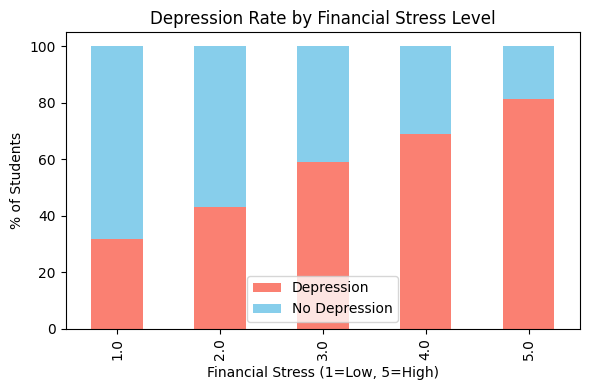

In [28]:
ct = pd.crosstab(data["Financial Stress"], data["Depression Status"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(6, 4))
ct.plot(kind="bar", stacked=True, ax=ax, color=['salmon','skyblue',])
ax.set_title("Depression Rate by Financial Stress Level")
ax.set_xlabel("Financial Stress (1=Low, 5=High)")
ax.set_ylabel("% of Students")
ax.legend(title="")
plt.tight_layout()
plt.show()


#### Sleep duration vs. depression

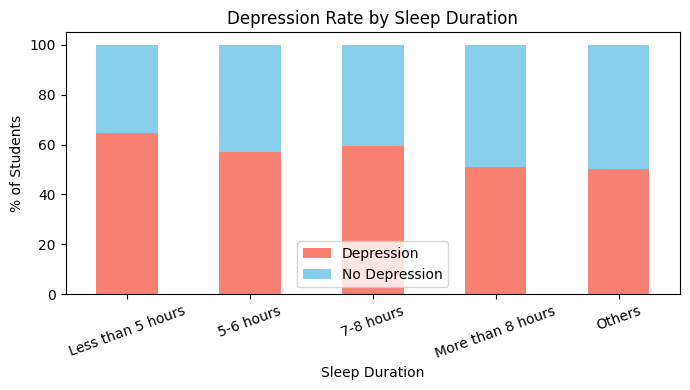

In [30]:
order = ["Less than 5 hours", "5-6 hours", "7-8 hours", "More than 8 hours", "Others"]
ct = pd.crosstab(data["Sleep Duration"], data["Depression Status"], normalize="index").reindex(order) * 100

fig, ax = plt.subplots(figsize=(7, 4))
ct.plot(kind="bar", stacked=True, ax=ax, color=['salmon','skyblue',])
ax.set_title("Depression Rate by Sleep Duration")
ax.set_ylabel("% of Students")
ax.legend(title="")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


#### Correlation Overview

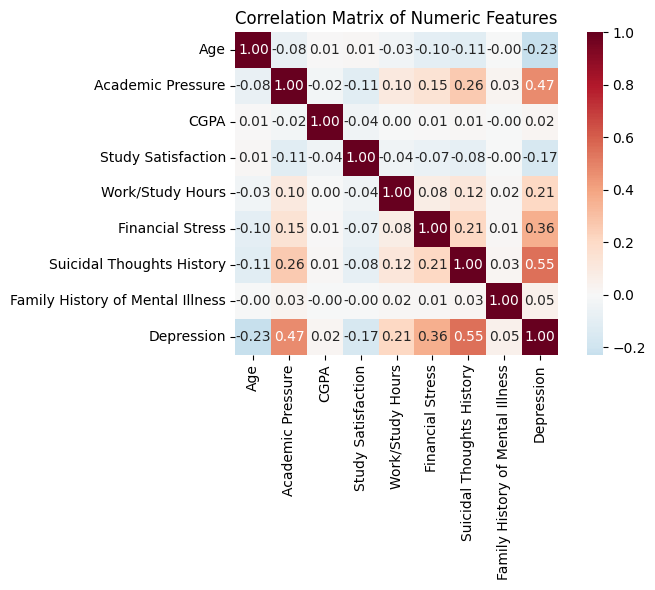

Suicidal Thoughts History           0.546491
Academic Pressure                   0.474785
Financial Stress                    0.363450
Age                                -0.226904
Work/Study Hours                    0.209159
Study Satisfaction                 -0.168338
Family History of Mental Illness    0.053517
CGPA                                0.021883
Name: Depression, dtype: float64

In [31]:
numeric_cols = ["Age", "Academic Pressure", "CGPA", "Study Satisfaction",
                 "Work/Study Hours", "Financial Stress", "Suicidal Thoughts History",
                 "Family History of Mental Illness", "Depression"]
corr = data[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

corr["Depression"].drop("Depression").sort_values(key=abs, ascending=False)

### Feaure Engineering and Train/Test Split

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
TARGET = "Depression"
y = data[TARGET]
X = data.drop(columns=[TARGET, "Depression Status"])

numeric_features = ["Age", "Academic Pressure", "CGPA", "Study Satisfaction",
                     "Work/Study Hours", "Financial Stress"]
binary_features = ["Gender", "Suicidal Thoughts History", "Family History of Mental Illness"]
categorical_features = ["City", "Sleep Duration", "Dietary Habits", "Degree"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("bin", "passthrough", binary_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 22274, Test size: 5569


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, roc_curve)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

results = {}
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, proba),
    }
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).T.round(4)
results_df


c:\Users\Oneli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Oneli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Oneli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Oneli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zer

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8511,0.8618,0.8880,0.8747,0.9208
Decision Tree,0.8303,0.8352,0.8846,0.8592,0.9021
Random Forest,0.8423,0.8391,0.9040,0.8703,0.9165
Gradient Boosting,0.8483,0.8579,0.8877,0.8726,0.9222


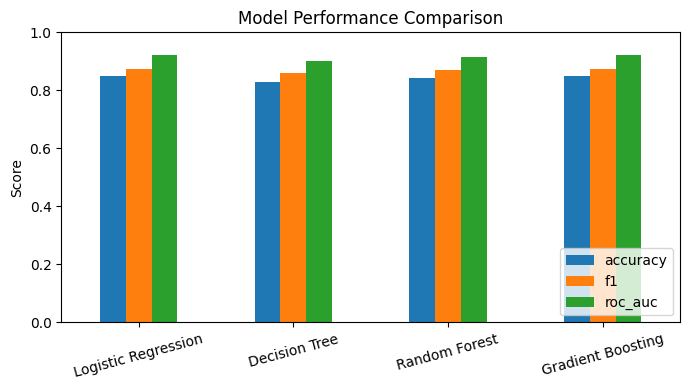

In [34]:
fig, ax = plt.subplots(figsize=(7, 4))
results_df[["accuracy", "f1", "roc_auc"]].plot(kind="bar", ax=ax)
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Best model by ROC-AUC: Gradient Boosting


c:\Users\Oneli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


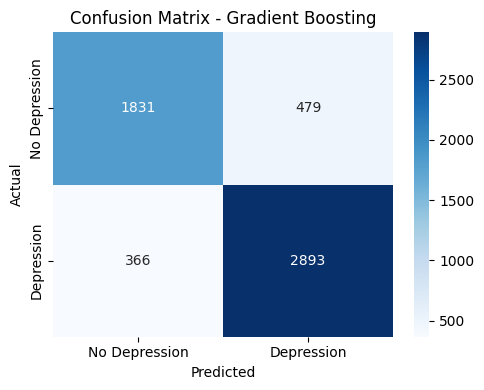

In [35]:
best_name = results_df["roc_auc"].idxmax()
best_pipe = fitted_pipelines[best_name]
print(f"Best model by ROC-AUC: {best_name}")

preds_best = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, preds_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Depression", "Depression"],
            yticklabels=["No Depression", "Depression"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.show()


c:\Users\Oneli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Oneli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Oneli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
c:\Users\Oneli\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zer

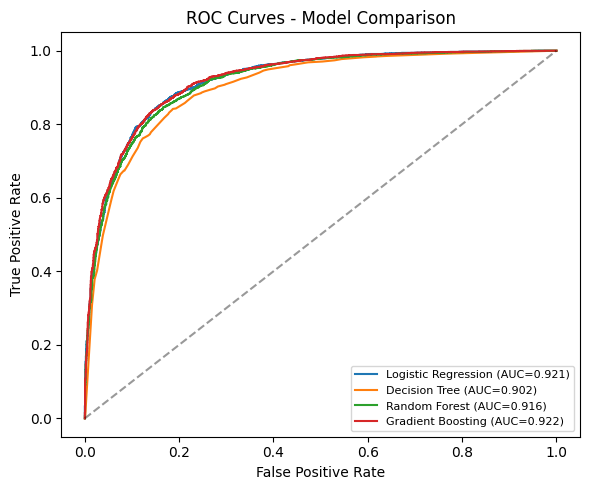

In [36]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, pipe in fitted_pipelines.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - Model Comparison")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Feature Importance and Key Findings

Using the Random Forest model (most interpretable of the strong performers),
we extract which features matter most for predicting depression.

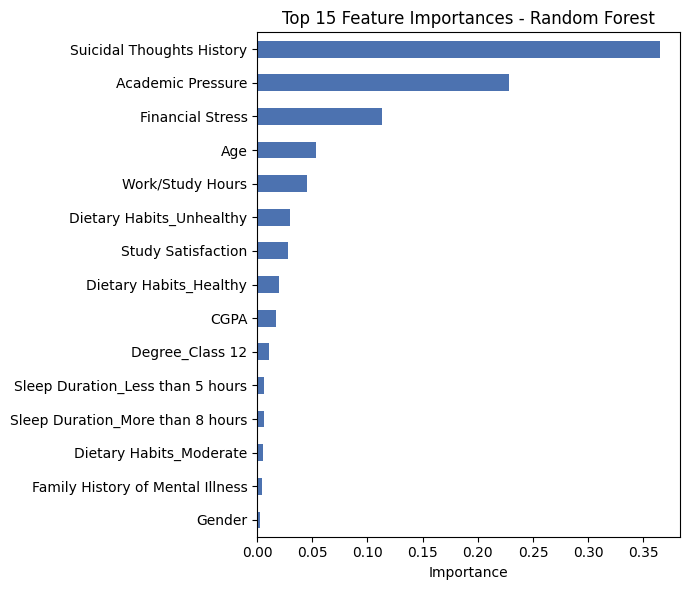

Suicidal Thoughts History    0.364935
Academic Pressure            0.227855
Financial Stress             0.113054
Age                          0.053227
Work/Study Hours             0.044937
Dietary Habits_Unhealthy     0.030153
Study Satisfaction           0.028122
Dietary Habits_Healthy       0.020233
CGPA                         0.016915
Degree_Class 12              0.011010
dtype: float64

In [37]:
rf_pipe = fitted_pipelines["Random Forest"]
feature_names = (
    numeric_features
    + binary_features
    + list(rf_pipe.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(categorical_features))
)
importances = rf_pipe.named_steps["model"].feature_importances_
imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 6))
imp_series.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Top 15 Feature Importances - Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

imp_series.head(10)


### Summary of findings

- **History of suicidal thoughts** is by far the strongest predictor of current
  depression in this sample, followed by **academic pressure** and **financial stress**. 
  These three factors that together account for the majority of the model's predictive signal.
- **CGPA has almost no relationship with depression** (correlation ~ 0.02). Academic
  *performance* doesn't appear to drive depression nearly as much as academic
  *pressure* does which is an important distinction for any intervention design.
- Students reporting **less sleep** and **higher work/study hours** show
  meaningfully higher depression rates.
- The best model (Gradient Boosting) reaches **~85% accuracy and ~0.92 ROC-AUC**,
  indicating these self-reported lifestyle and stress factors carry strong
  predictive signal for depression risk, though of course this is observational
  survey data and the model identifies association, not causation.
- **Caveat:** all features are self-reported and cross-sectional (collected at a
  single point in time), so the model is best read as identifying *risk
  correlates* to flag for follow-up -- not as a diagnostic or causal tool.
